In [29]:
import yfinance as yf
import pandas as pd
from pandas_datareader import data as pdr
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [30]:
tickers = ['TD.TO','RY.TO','CM.TO','BNS.TO','BMO.TO']
raw = yf.download(tickers, start='2021-01-01', end='2024-01-01')['Close']


[*********************100%***********************]  5 of 5 completed


In [31]:
print(raw.isnull().sum())

Ticker
BMO.TO    0
BNS.TO    0
CM.TO     0
RY.TO     0
TD.TO     0
dtype: int64


In [32]:
raw = raw.ffill()
print(raw)


Ticker          BMO.TO     BNS.TO      CM.TO       RY.TO      TD.TO
Date                                                               
2021-01-04   76.617767  51.146858  42.331352   86.141037  57.233871
2021-01-05   76.992882  51.305462  42.774178   86.692375  57.528240
2021-01-06   78.381737  51.735966  43.585381   87.951416  59.159164
2021-01-07   79.211853  52.106056  43.789165   88.930672  59.553192
2021-01-08   79.706726  51.403652  44.090912   88.856598  59.593399
...                ...        ...        ...         ...        ...
2023-12-21  116.838165  55.219082  57.197899  123.017044  76.334518
2023-12-22  117.788010  55.570118  57.974869  123.553162  76.676826
2023-12-27  118.936852  56.079132  58.350559  124.070755  77.109222
2023-12-28  118.213165  56.368744  58.185619  123.895126  76.793938
2023-12-29  118.602150  56.605705  58.460514  123.858154  77.127251

[751 rows x 5 columns]


In [33]:
raw.columns = ['BNS','RY','TD','BMO','CM']
print(raw.columns)

Index(['BNS', 'RY', 'TD', 'BMO', 'CM'], dtype='object')


In [34]:
returns = raw.pct_change().dropna()
print(returns)


                 BNS        RY        TD       BMO        CM
Date                                                        
2021-01-05  0.004896  0.003101  0.010461  0.006400  0.005143
2021-01-06  0.018039  0.008391  0.018965  0.014523  0.028350
2021-01-07  0.010591  0.007153  0.004676  0.011134  0.006660
2021-01-08  0.006247 -0.013480  0.006891 -0.000833  0.000675
2021-01-11  0.000100  0.000000  0.003288 -0.001297  0.001214
...              ...       ...       ...       ...       ...
2023-12-21  0.013735  0.009142  0.012474  0.005743  0.016555
2023-12-22  0.008130  0.006357  0.013584  0.004358  0.004484
2023-12-27  0.009753  0.009160  0.006480  0.004189  0.005639
2023-12-28 -0.006085  0.005164 -0.002827 -0.001416 -0.004089
2023-12-29  0.003291  0.004204  0.004724 -0.000298  0.004340

[750 rows x 5 columns]


In [35]:
cumulative = (1 + returns).cumprod() - 1
print(cumulative)

                 BNS        RY        TD       BMO        CM
Date                                                        
2021-01-05  0.004896  0.003101  0.010461  0.006400  0.005143
2021-01-06  0.023023  0.011518  0.029624  0.021016  0.033639
2021-01-07  0.033857  0.018754  0.034438  0.032385  0.040524
2021-01-08  0.040316  0.005021  0.041566  0.031525  0.041226
2021-01-11  0.040421  0.005021  0.044991  0.030187  0.042491
...              ...       ...       ...       ...       ...
2023-12-21  0.524949  0.079618  0.351195  0.428089  0.333730
2023-12-22  0.537346  0.086482  0.369549  0.434312  0.339711
2023-12-27  0.552340  0.096434  0.378424  0.440321  0.347266
2023-12-28  0.542895  0.102096  0.374528  0.438282  0.341757
2023-12-29  0.547972  0.106729  0.381022  0.437853  0.347581

[750 rows x 5 columns]


In [36]:
# 5. Calculate cumulative returns in %
cum_returns = (raw / raw.iloc[0] - 1) * 100
print(cum_returns)

                  BNS         RY         TD        BMO         CM
Date                                                             
2021-01-04   0.000000   0.000000   0.000000   0.000000   0.000000
2021-01-05   0.489592   0.310095   1.046093   0.640041   0.514326
2021-01-06   2.302298   1.151796   2.962410   2.101645   3.363905
2021-01-07   3.385750   1.875380   3.443815   3.238450   4.052357
2021-01-08   4.031648   0.502072   4.156635   3.152459   4.122607
...               ...        ...        ...        ...        ...
2023-12-21  52.494871   7.961826  35.119470  42.808873  33.372977
2023-12-22  53.734589   8.648155  36.954918  43.431245  33.971064
2023-12-27  55.234035   9.643356  37.842417  44.032112  34.726553
2023-12-28  54.289494  10.209592  37.452777  43.828227  34.175683
2023-12-29  54.797189  10.672888  38.102165  43.785307  34.758053

[751 rows x 5 columns]


In [37]:
ann_return = returns.mean() * 252 
print(ann_return)

BNS    0.162030
RY     0.048285
TD     0.124892
BMO    0.132485
CM     0.114477
dtype: float64


In [38]:
ann_vol = returns.std() * (252 ** 0.5)
print(ann_vol)

BNS    0.174189
RY     0.168474
TD     0.180881
BMO    0.144321
CM     0.168648
dtype: float64


In [39]:
sharpe = ann_return / ann_vol
print(sharpe)

BNS    0.930197
RY     0.286599
TD     0.690463
BMO    0.917987
CM     0.678789
dtype: float64


In [40]:
corr = returns.corr()
print(corr)

          BNS        RY        TD       BMO        CM
BNS  1.000000  0.718355  0.744342  0.766524  0.731077
RY   0.718355  1.000000  0.683819  0.661548  0.661662
TD   0.744342  0.683819  1.000000  0.716358  0.596615
BMO  0.766524  0.661548  0.716358  1.000000  0.665785
CM   0.731077  0.661662  0.596615  0.665785  1.000000


In [41]:
 summary = pd.DataFrame({'Ann. Return': ann_return, 'Ann. Volatility': ann_vol, 'Sharpe Ratio': sharpe}).round(4)
print(summary)

     Ann. Return  Ann. Volatility  Sharpe Ratio
BNS       0.1620           0.1742        0.9302
RY        0.0483           0.1685        0.2866
TD        0.1249           0.1809        0.6905
BMO       0.1325           0.1443        0.9180
CM        0.1145           0.1686        0.6788


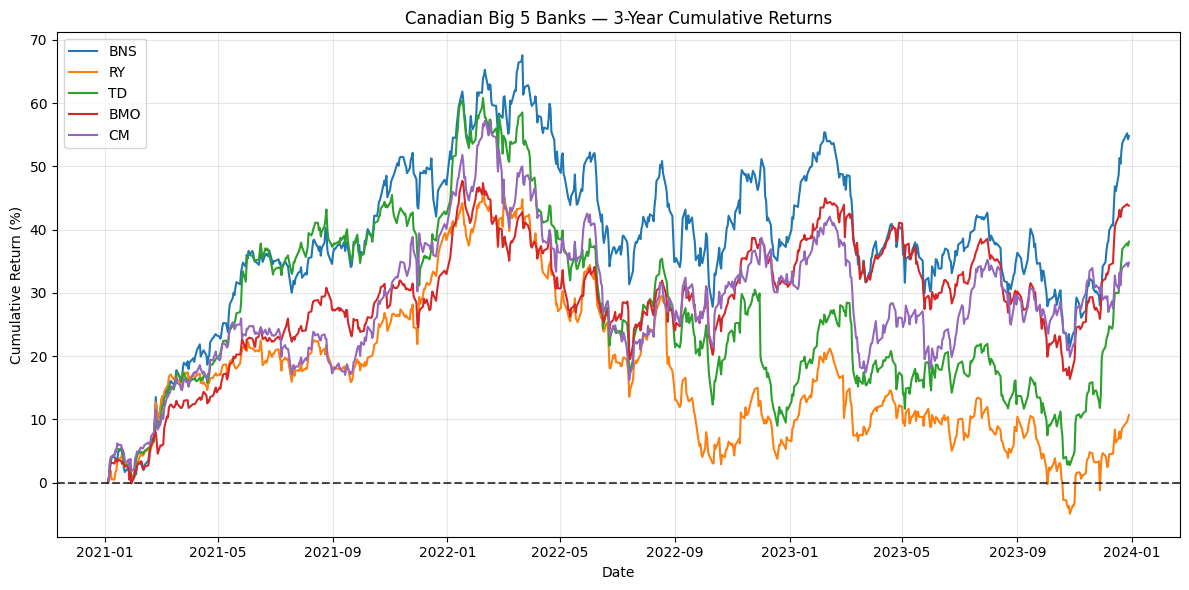

In [48]:
plt.figure(figsize=(12,6))
# 7. Plot each bank's cumulative return line
for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col)
# 8. Add a horizontal line at 0%
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
# 9. Add title and axis labels
plt.title('Canadian Big 5 Banks — 3-Year Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
# 10. Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)
# 11. Make layout neat and show the chart
plt.tight_layout()
plt.savefig('3-Year Cumulative Return.png', dpi=150, bbox_inches='tight')
plt.show()






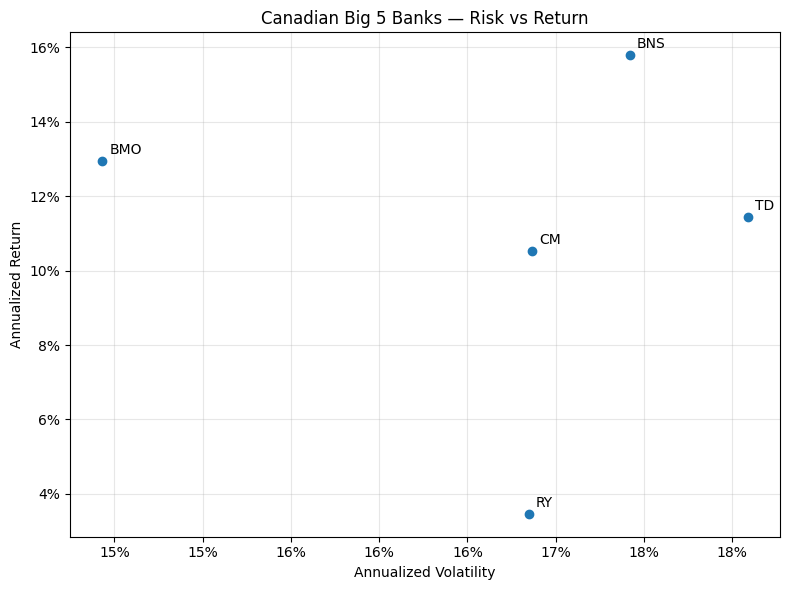

In [49]:
# 1. Calculate daily returns from price data
daily_returns = raw.pct_change().dropna()
# 2. Annualized return for each bank (using total return over the whole period)
total_return = raw.iloc[-1] / raw.iloc[0] - 1
years = len(raw) / 252
ann_return = (1 + total_return) ** (1 / years) - 1
# 3. Annualized volatility for each bank (standard deviation of daily returns * sqrt(252))
ann_vol = daily_returns.std() * np.sqrt(252)
# 4. Make the scatter plot (risk vs return)
plt.figure(figsize=(8, 6))
plt.scatter(ann_vol, ann_return)
# 5. Add a label next to each point (each bank)
for ticker in ann_return.index:
    plt.annotate(
        ticker,
        (ann_vol[ticker], ann_return[ticker]),
        xytext=(5, 5),
        textcoords='offset points'
    )
# 6. Add axis labels and title
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Canadian Big 5 Banks — Risk vs Return')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Risk vs Return.png', dpi=150, bbox_inches='tight')
plt.show()





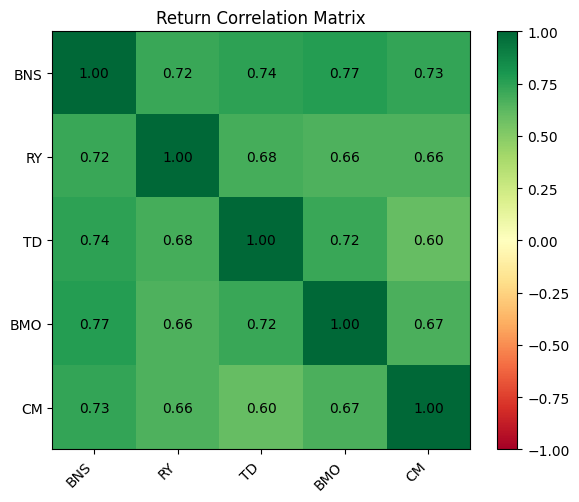

In [46]:
# 2. Compute correlation matrix between banks (based on daily returns)
corr = daily_returns.corr()
# 3. Plot the correlation heatmap
plt.figure(figsize=(6, 5))
im = plt.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)
# 4. Put bank names on x and y axes
tick_labels = corr.columns
plt.xticks(range(len(tick_labels)), tick_labels, rotation=45, ha='right')
plt.yticks(range(len(tick_labels)), tick_labels)
# 5. Add the correlation numbers on each square
for i in range(len(tick_labels)):
    for j in range(len(tick_labels)):
        value = corr.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",
            ha='center', va='center',
            color='black'
        )
# 6. Add title and tidy layout
plt.title('Return Correlation Matrix')
plt.tight_layout()
plt.savefig('Return Correlation Matrix.png', dpi=150, bbox_inches='tight')
plt.show()





In [45]:
writer = pd.ExcelWriter('Bank_Portfolio_Report.xlsx', engine='openpyxl')
raw.to_excel(writer, sheet_name='Price Data')
returns.to_excel(writer, sheet_name='Daily Returns')
summary.to_excel(writer, sheet_name='Summary Metrics')
corr.to_excel(writer, sheet_name='Correlation')
writer.close()
